# ML Assignment 02
### Dataset: House Price Prediction Dataset
### Total Marks: 100

---

## Exam Instructions:
1. প্রথমে নিচের cell এ নিজের **নাম** এবং কোর্সে registration করা **ইমেইল** দিবে
2. Question wise numbering করে Text cell রাখবে এবং এর নিচে Code cell থাকবে, চেষ্টা করবে একটি code cell এ একটি question উত্তর দেওয়ার
3. Google Colab এর মধ্যে কোডগুলো করবে
4. এবং সেই ফাইলটি **'Anyone with the link' & 'View' Access** দিয়ে ফাইলটির Shareable Link টি সাবমিট করবে

---

**Question Dataset Link:** https://www.kaggle.com/datasets/prokshitha/home-value-insights

## Student Information

In [185]:
# Fill in your information
name = ""           # Write your full name here
email = ""          # Write your registered email here

print(f"Name  : {name}")
print(f"Email : {email}")

Name  : 
Email : 


---
## Question 1 (10 Marks)

Load the House Price dataset and display:
- Dataset shape
- First 10 rows
- 5 random samples

In [186]:
# Question 1
import pandas as pd
import kagglehub

# Download latest version
kagglehub.dataset_download("prokshitha/home-value-insights", output_dir="./dataSet")
rawDF = pd.read_csv("dataSet/house_price_regression_dataset.csv")
print(f"Shape: {rawDF.shape}")
display(rawDF.iloc[:10, :])
display(rawDF.sample(5))

Shape: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
5,3944,5,3,1990,2.475930,2,8,8.797970e+05
6,3671,1,2,2012,4.911960,0,1,8.144279e+05
7,3419,1,1,1972,2.805281,1,1,7.034131e+05
8,630,3,3,1997,1.014286,1,8,1.738750e+05
9,2185,4,2,1981,3.941604,2,5,5.041765e+05


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
182,2234,2,2,1985,3.372450,2,10,5.078476e+05
50,2455,3,2,1953,4.951480,0,10,5.273935e+05
620,4079,5,3,2007,1.476303,1,10,9.098361e+05
818,1754,2,2,1998,0.919722,2,4,3.988233e+05
518,4798,5,1,1997,3.345072,2,1,1.045202e+06


---
## Question 2 (10 Marks)

Handle missing values and perform feature engineering:
- Impute missing numerical values using `SimpleImputer` with mean strategy
- Impute missing categorical values using most frequent strategy
- Drop columns with more than 50% missing values
- Perform train-test split with `test_size=0.2` and `random_state=42`

Display the shape of final train and test sets.

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64
Since there is no null value, we do not have to drop columns with more than 50% missing values.
(1000, 8)


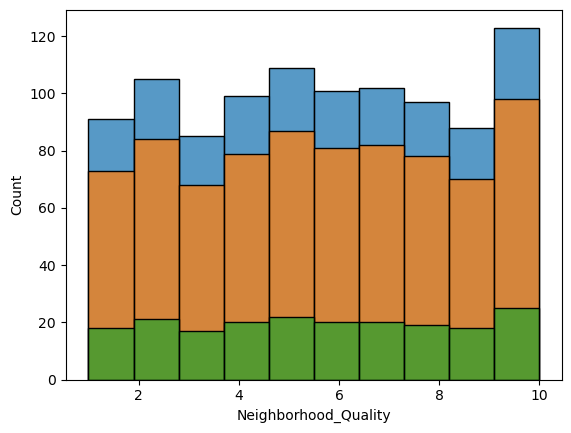

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
438,895.0,1.0,3.0,2021.0,2.146486,1.0,6.0,235478.102134
886,3572.0,4.0,3.0,1958.0,0.691115,1.0,3.0,729385.552404
342,4172.0,5.0,3.0,1956.0,2.795668,1.0,10.0,894611.078656
948,2401.0,2.0,1.0,1988.0,1.883884,1.0,6.0,504682.301248
642,1171.0,3.0,1.0,1958.0,0.693736,1.0,6.0,206781.757443
...,...,...,...,...,...,...,...,...
297,2868.0,1.0,2.0,1986.0,0.943623,1.0,10.0,581948.159951
139,4263.0,2.0,3.0,1953.0,4.361542,1.0,4.0,893926.629472
798,4097.0,5.0,1.0,1951.0,2.753199,2.0,4.0,852599.975056
401,1275.0,5.0,3.0,2006.0,2.191123,1.0,4.0,354189.005477


((800, 8), (200, 8))

In [187]:
#Question 2
from sklearn.impute import  SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt 
import seaborn as sns

imputer = SimpleImputer(strategy="mean")
imputerCat = SimpleImputer(strategy="most_frequent")
print(rawDF.iloc[:,:8].isnull().sum())
print("Since there is no null value, we do not have to drop columns with more than 50% missing values.")
rawDF = pd.DataFrame(
    imputer.fit_transform(rawDF),
    columns=rawDF.columns,
    index=rawDF.index
)
rawDF["Neighborhood_Quality"] = imputerCat.fit_transform(rawDF[["Neighborhood_Quality"]]).ravel()
print(rawDF.shape)
spliter = StratifiedShuffleSplit(test_size=0.2, random_state=42, n_splits=1)

trainSet = []
testSet = []
sns.histplot(data=rawDF, x="Neighborhood_Quality", bins=10)
for trainIndex, testIndex in spliter.split(rawDF, rawDF["Neighborhood_Quality"]):
    trainSet = rawDF.iloc[trainIndex,:]
    testSet = rawDF.iloc[testIndex, :]

sns.histplot(data=trainSet, x="Neighborhood_Quality", bins=10)
sns.histplot(data=testSet, x="Neighborhood_Quality", bins=10)
plt.show()
display(trainSet)
trainSet.shape, testSet.shape

---
## Question 3 (20 Marks)

Implement **Simple Linear Regression** using **only NumPy** (no Scikit-Learn allowed):
- Compute slope (`m`) and intercept (`c`) using the Batch Gradient Descent
- Predict values for the test set
- Print the learned `m` and `c` values

Use `Square_Footage` as feature (X) and `House_Price` as target (y).

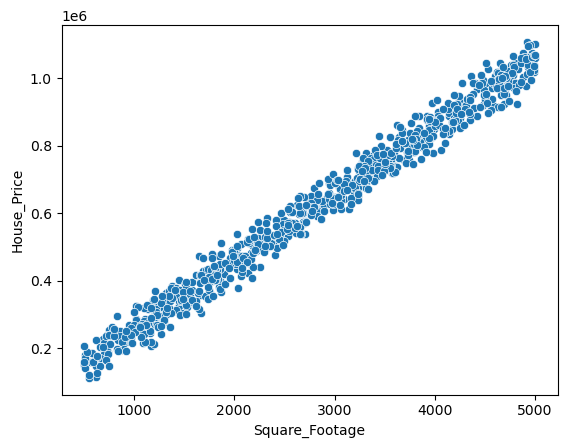

Learned m: 200.00788355743416
Learned c: 55118.50945115986
RMSE: 31757.195708928462
Accuracy (R²): 0.9821523108291308


In [188]:
#Question 3




import numpy as np


sns.scatterplot(data=trainSet, x="Square_Footage", y="House_Price")
plt.show()

X_train = trainSet["Square_Footage"].to_numpy(dtype=float)
y_train = trainSet["House_Price"].to_numpy(dtype=float)

X_test = testSet["Square_Footage"].to_numpy(dtype=float)
y_test = testSet["House_Price"].to_numpy(dtype=float)

x_mean = X_train.mean()
x_std = X_train.std()
X_train_s = (X_train - x_mean) / x_std
X_test_s = (X_test - x_mean) / x_std

m_s = 0.0
c_s = 0.0
learning_rate = 0.000001
totalStep = 179999999
n = len(X_train_s)

for _ in range(totalStep):
    y_pred = m_s * X_train_s + c_s
    error = y_pred - y_train

    dm = (2 / n) * np.dot(error, X_train_s)
    dc = (2 / n) * np.sum(error)

    m_s -= learning_rate * dm
    c_s -= learning_rate * dc

m = m_s / x_std
c = c_s - (m_s * x_mean / x_std)

y_pred_test = m * X_test + c

print("Learned m:", m)
print("Learned c:", c)

rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
print("RMSE:", rmse)
ss_res = np.sum((y_test - y_pred_test) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

accuracy = 1 - (ss_res / ss_tot)

print("Accuracy (R²):", accuracy)

---
## Question 4 (10 Marks)

Build a **ColumnTransformer** that applies:
- `StandardScaler` on numerical columns: `Square_Footage`, `Num_Bedrooms`, `Num_Bathrooms`
- `OneHotEncoder` on categorical column: `Neighborhood_Quality`



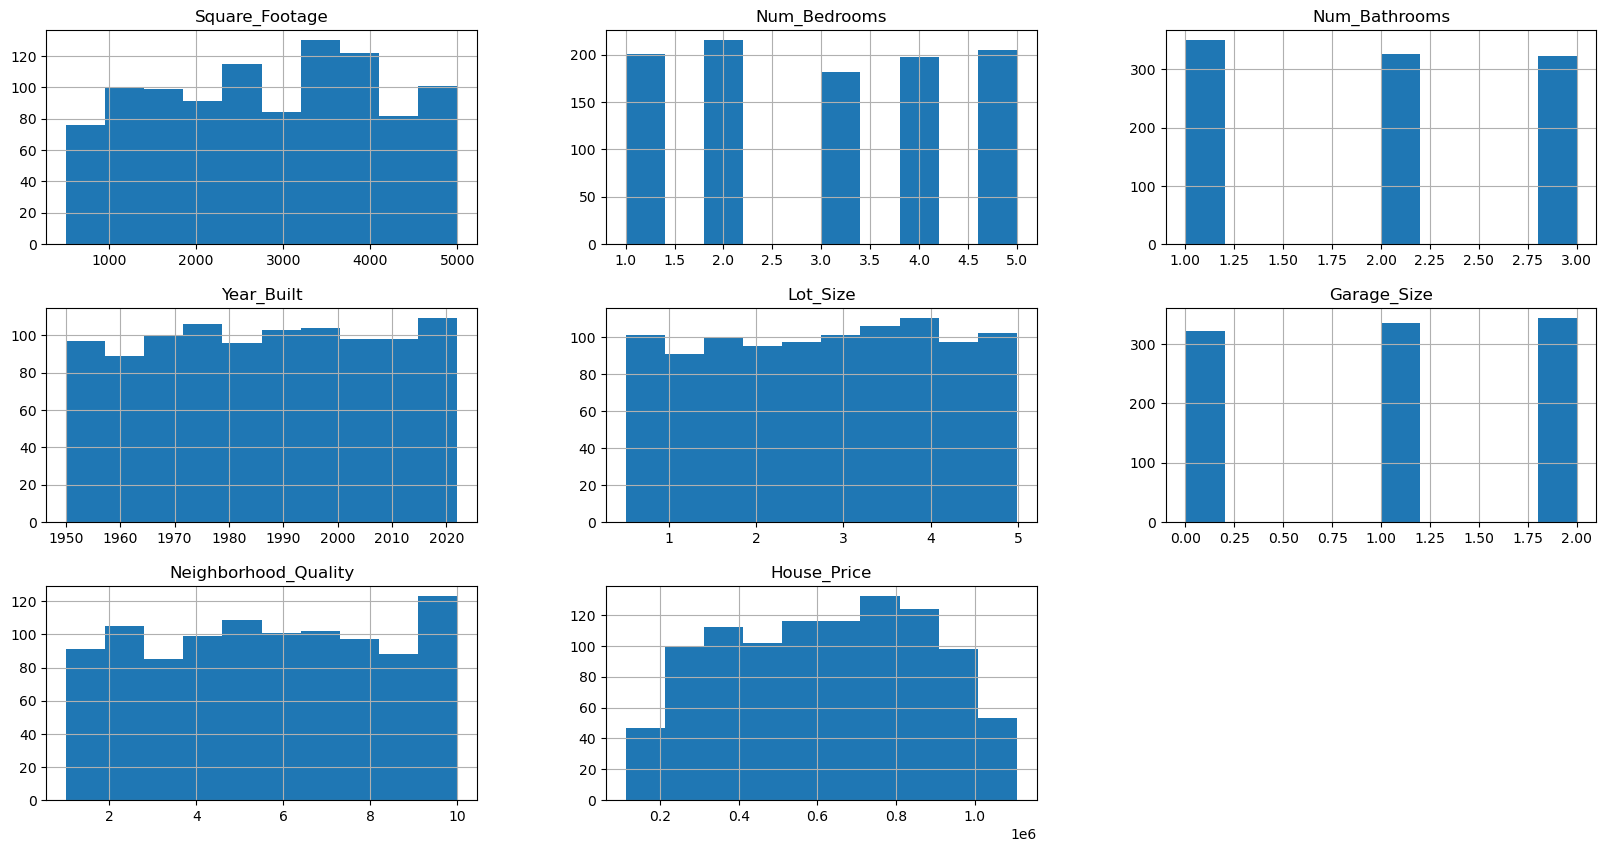

In [189]:
#Question 4
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

rawDF.hist(figsize=(20,10), bins=10)
defaultNumPipeline = Pipeline(
    [
        ("Impute", SimpleImputer(strategy="median")),
        ("Scale", StandardScaler())
    ]
)

defaultCatPipeline = Pipeline(
    [
        ("Impute", SimpleImputer(strategy="most_frequent")),
        ("Encode", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessing = ColumnTransformer(
    [
        ("NumCol", defaultNumPipeline, ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Neighborhood_Quality", "Year_Built", "Lot_Size", "Garage_Size"]),
        ("CatCol", defaultCatPipeline, ["Neighborhood_Quality"])
    ]
)

## Question 5 (20 Marks)

Build a complete **Pipeline** using Scikit-Learn that includes:
- The `ColumnTransformer`
- `SGDRegressor` as the final estimator
- Train the pipeline and evaluate using RMSE and R² score
- Print predicted vs actual values for the first 10 test samples

In [190]:
# Question 5
from sklearn.linear_model import  SGDRegressor
from xgboost import XGBRegressor

print("---------------SGDRegressor---------------")
modelPipeline = Pipeline(
    [
        ("Preprocess", preprocessing),
        ("Model", SGDRegressor(
    loss="squared_error",
    penalty="elasticnet",
    alpha=1e-5,
    l1_ratio=0.15,
    learning_rate="adaptive",
    eta0=0.05,
    max_iter=999999999,
    tol=1e-6,
    early_stopping=False,
    shuffle=True,
    average=True,
    random_state=67
))
    ]
)

modelPipeline.fit(trainSet.drop(columns=["House_Price"]), trainSet["House_Price"])

y_pred_test = modelPipeline.predict(testSet.drop(columns=["House_Price"]))

y_test = testSet["House_Price"]

rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
print("RMSE:", rmse)
ss_res = np.sum((y_test - y_pred_test) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

accuracy = 1 - (ss_res / ss_tot)

print("Accuracy (R²):", accuracy)



# First 10 predictions
print("\nFirst 10 Predictions vs Actual:")
for pred, actual in zip(y_pred_test[:10], y_test.iloc[:10]):
    print(f"Predicted: {pred:.2f} | Actual: {actual:.2f}")
    print(f"Off by: {actual-pred}$")

---------------SGDRegressor---------------
RMSE: 10841.722828286329
Accuracy (R²): 0.9979198516754101

First 10 Predictions vs Actual:
Predicted: 879241.32 | Actual: 897176.57
Off by: 17935.25176082179$
Predicted: 771828.53 | Actual: 788471.75
Off by: 16643.213358788635$
Predicted: 966734.66 | Actual: 964865.30
Off by: -1869.3600207089912$
Predicted: 885785.92 | Actual: 868356.24
Off by: -17429.67307851964$
Predicted: 1020313.49 | Actual: 1015603.70
Off by: -4709.790427180473$
Predicted: 855764.89 | Actual: 866877.35
Off by: 11112.466441137134$
Predicted: 424737.52 | Actual: 412045.78
Off by: -12691.733045556291$
Predicted: 760237.68 | Actual: 760720.15
Off by: 482.4678218907211$
Predicted: 796683.29 | Actual: 793323.81
Off by: -3359.481037066318$
Predicted: 711354.05 | Actual: 695362.74
Off by: -15991.307222722098$


---
## Question 6 (20 Marks)

Implement **Multiple Linear Regression** using **Scikit-Learn**:
- The `ColumnTransformer`
- `LinearRegression` as the final estimator
- Train the pipeline and evaluate using RMSE and R² score
- Print predicted vs actual values for the first 10 test samples

In [191]:
# Question 6
# Question 5
from sklearn.linear_model import  LinearRegression

print("---------------LinearRegression---------------")
modelPipeline = Pipeline(
    [
        ("Preprocess", preprocessing),
        ("Model", LinearRegression(
    fit_intercept=True,
    copy_X=True,
    n_jobs=-1,
    positive=False
))
    ]
)

modelPipeline.fit(trainSet.drop(columns=["House_Price"]), trainSet["House_Price"])

y_pred_test = modelPipeline.predict(testSet.drop(columns=["House_Price"]))

y_test = testSet["House_Price"]

rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
print("RMSE:", rmse)
ss_res = np.sum((y_test - y_pred_test) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

accuracy = 1 - (ss_res / ss_tot)

print("Accuracy (R²):", accuracy)



# First 10 predictions
print("\nFirst 10 Predictions vs Actual:")
for pred, actual in zip(y_pred_test[:10], y_test.iloc[:10]):
    print(f"Predicted: {pred:.2f} | Actual: {actual:.2f}")
    print(f"Off by: {actual-pred}$")

---------------LinearRegression---------------
RMSE: 10838.75289229176
Accuracy (R²): 0.9979209911734965

First 10 Predictions vs Actual:
Predicted: 879401.06 | Actual: 897176.57
Off by: 17775.50610431668$
Predicted: 771922.76 | Actual: 788471.75
Off by: 16548.986140556866$
Predicted: 967009.99 | Actual: 964865.30
Off by: -2144.688234815374$
Predicted: 885907.61 | Actual: 868356.24
Off by: -17551.36814661906$
Predicted: 1020415.17 | Actual: 1015603.70
Off by: -4811.467112705228$
Predicted: 855873.53 | Actual: 866877.35
Off by: 11003.82650828571$
Predicted: 424666.79 | Actual: 412045.78
Off by: -12621.002585097973$
Predicted: 760367.66 | Actual: 760720.15
Off by: 352.48489370488096$
Predicted: 796869.54 | Actual: 793323.81
Off by: -3545.7237695602234$
Predicted: 711390.49 | Actual: 695362.74
Off by: -16027.744537884952$


---
## Question 7 (10 Marks) (You have to explore the topic and use the equation via Numpy)
### Dont use LLMs , You can use Documentation

Implement **Multiple Linear Regression** using **only NumPy**:
- Pick random 100 datas from the dataset
- Use the Normal Equation: `θ = (XᵀX)⁻¹ Xᵀy`
- Use `Square_Footage`, `Num_Bedrooms`, and `Num_Bathrooms` as features
- Print the learned coefficients (θ values)

In [192]:
# Question 7
import numpy as np


sampleDF = rawDF.sample(n=100, random_state=42)


X = sampleDF[["Square_Footage", "Num_Bedrooms", "Num_Bathrooms"]].to_numpy(dtype=float)
y = sampleDF["House_Price"].to_numpy(dtype=float).reshape(-1, 1)


X_b = np.c_[np.ones((X.shape[0], 1)), X]


theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

print("Learned coefficients (theta):")
print("theta_0 (intercept):", theta[0, 0])
print("theta_1 (Square_Footage):", theta[1, 0])
print("theta_2 (Num_Bedrooms):", theta[2, 0])
print("theta_3 (Num_Bathrooms):", theta[3, 0])

Learned coefficients (theta):
theta_0 (intercept): 20888.259447982793
theta_1 (Square_Footage): 202.3082079206385
theta_2 (Num_Bedrooms): 8303.281041634516
theta_3 (Num_Bathrooms): 3020.3285224887313
